# Rossmann Store Sales: Exploratory Data Analysis

## 1. Data Loading and Initial Inspection

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("../data/raw/train.csv")
test  = pd.read_csv("../data/raw/test.csv")
store = pd.read_csv("../data/raw/store.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Store shape:", store.shape)


Train shape: (1017209, 9)
Test shape: (41088, 8)
Store shape: (1115, 10)


C:\Users\prade\AppData\Local\Temp\ipykernel_3556\604984617.py:6: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


In [104]:
train.head()


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [105]:
test.head()


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [106]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [107]:
print("TRAIN COlOUMNS")
print(train.columns.tolist())



TRAIN COlOUMNS
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']


In [108]:
print("\n TRAIN DATA TYPES")
print(train.dtypes)
# Note : except Date, StateHoliday rest and int values


 TRAIN DATA TYPES
Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object


In [109]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [110]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


## 2. Data Quality and Missing Values

In [111]:
print("Train missing values")
train.isnull().sum()

Train missing values


Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [112]:
print("Store missing values:")
store.isnull().sum()

Store missing values:


Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [113]:
# frequency of values for in each column
for col in train.columns:
    print(f"\n{'='*40}")
    print(train[col].value_counts().head(10))
    print(train[col].value_counts().head(10).sum()) # first 10 vals


Store
1      942
726    942
708    942
709    942
713    942
714    942
715    942
717    942
718    942
720    942
Name: count, dtype: int64
9420

DayOfWeek
5    145845
4    145845
3    145665
2    145664
1    144730
7    144730
6    144730
Name: count, dtype: int64
1017209

Date
2015-07-31    1115
2013-11-06    1115
2013-11-18    1115
2013-11-17    1115
2013-11-16    1115
2013-11-15    1115
2013-11-14    1115
2013-11-13    1115
2013-11-12    1115
2013-11-11    1115
Name: count, dtype: int64
11150

Sales
0       172871
5674       215
5558       197
5483       196
6214       195
6049       195
5723       194
5449       192
5140       191
5489       191
Name: count, dtype: int64
174637

Customers
0      172869
560      2414
576      2363
603      2337
571      2330
555      2328
566      2327
517      2326
539      2309
651      2299
Name: count, dtype: int64
193902

Open
1    844392
0    172817
Name: count, dtype: int64
1017209

Promo
0    629129
1    388080
Name: count, dtype: int64


## 3. Time-Based Analysis

In [114]:
# the earliest and latest dates
train["Date"].min()
train["Date"].max()

'2015-07-31'

In [115]:
train["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [116]:
# 
train["Open"].value_counts()


Open
1    844392
0    172817
Name: count, dtype: int64

In [117]:
train["Promo"].value_counts()


Promo
0    629129
1    388080
Name: count, dtype: int64

In [118]:
train["StateHoliday"].value_counts()

StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

In [119]:
# Converted 'Date' column dtype from obj --> datetime
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])
print(train["Date"].dtype)

datetime64[ns]


In [120]:
# total of 942 days and 1115 stores
print("Number of unique dates:", train["Date"].nunique())
print("Number of stores:", train["Store"].nunique())


Number of unique dates: 942
Number of stores: 1115


In [121]:
print("Start date:", train["Date"].min())
print("End date:", train["Date"].max())

print("\nFirst 10 dates:")
print(train["Date"].head(2000))

Start date: 2013-01-01 00:00:00
End date: 2015-07-31 00:00:00

First 10 dates:
0      2015-07-31
1      2015-07-31
2      2015-07-31
3      2015-07-31
4      2015-07-31
          ...    
1995   2015-07-30
1996   2015-07-30
1997   2015-07-30
1998   2015-07-30
1999   2015-07-30
Name: Date, Length: 2000, dtype: datetime64[ns]


In [122]:
# Dates are in decreasing order (high to low)
train["Date"].is_monotonic_increasing

False

In [123]:
# Sort data in increasing order(low to high)
train = train.sort_values(["Date", "Store"]).reset_index(drop=True)

In [124]:
# Dates in order - 2013 -> 2014 -> 2015
print(train["Date"].head())
print()
print(train["Date"].tail())
print()
print(train["Date"].is_monotonic_increasing)

0   2013-01-01
1   2013-01-01
2   2013-01-01
3   2013-01-01
4   2013-01-01
Name: Date, dtype: datetime64[ns]

1017204   2015-07-31
1017205   2015-07-31
1017206   2015-07-31
1017207   2015-07-31
1017208   2015-07-31
Name: Date, dtype: datetime64[ns]

True


In [125]:
# Every Store has record for each day
daily_sales = train.groupby("Date")["Sales"].sum()
daily_sales.head()

Date
2013-01-01      97235
2013-01-02    6949829
2013-01-03    6347820
2013-01-04    6638954
2013-01-05    5951593
Name: Sales, dtype: int64

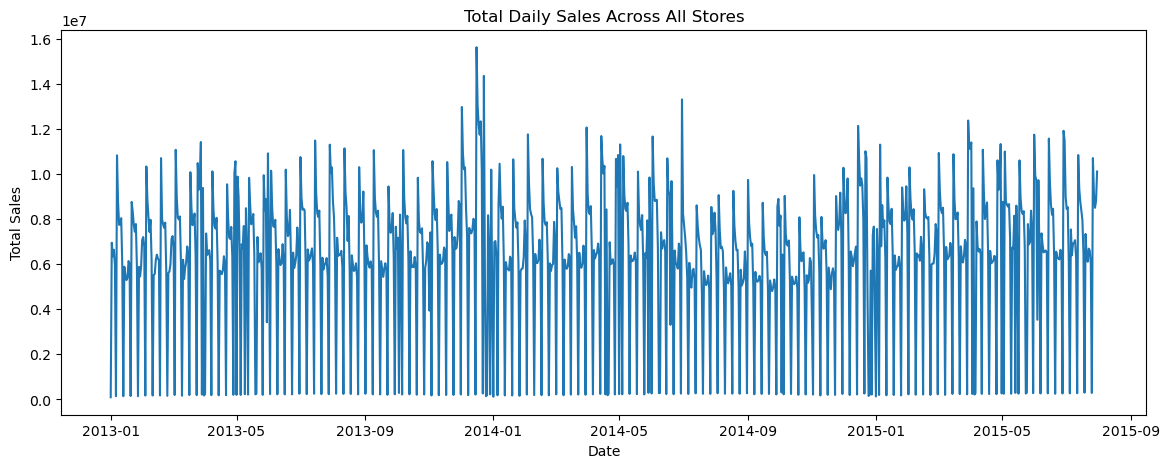

In [126]:
plt.figure(figsize=(14, 5))
plt.plot(daily_sales.index, daily_sales.values)

plt.title("Total Daily Sales Across All Stores")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

Total daily sales show strong recurring weekly patterns, with frequent sharp drops caused by store closures. This caused by holidays or stores being closed in general.

## 4. Day of Week Analysis

In [127]:
train.groupby("DayOfWeek")["Sales"].mean()

DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64

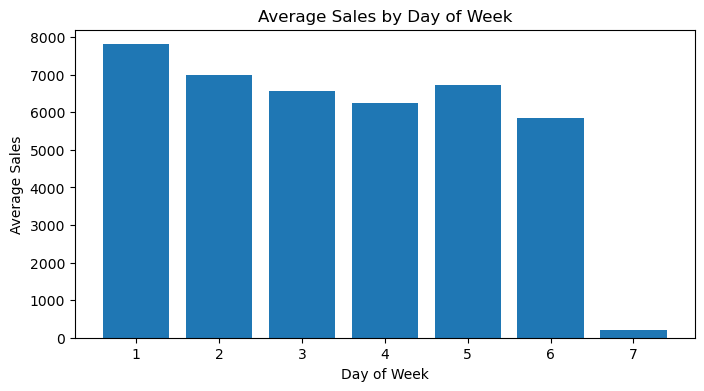

In [128]:
avg_sales_day = train.groupby("DayOfWeek")["Sales"].mean()

plt.figure(figsize=(8, 4))
plt.bar(avg_sales_day.index, avg_sales_day.values)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")

plt.xticks(range(1, 8))
plt.show()

Sunday has the lowest average sales, likely because many stores are closed on Sundays. While, Monday has the highest sales.

In [129]:
open_by_day = train.groupby("DayOfWeek")["Open"].mean()
print(open_by_day)

DayOfWeek
1    0.950459
2    0.988309
3    0.974400
4    0.923199
5    0.950598
6    0.995357
7    0.024826
Name: Open, dtype: float64


Sunday has the lowest average sales primarily because almost all stores are closed, with only about 2.5% of store-day records open.

## 5. Promotion Analysis

In [130]:
promo_sales = train.groupby("Promo")["Sales"].mean()
print(promo_sales)

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64


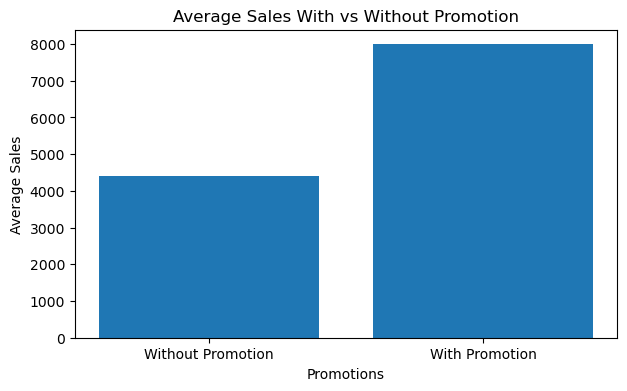

In [131]:
plt.figure(figsize=(7, 4))

plt.bar(promo_sales.index, promo_sales.values)

plt.title("Average Sales With vs Without Promotion")
plt.xlabel("Promotions")
plt.ylabel("Average Sales")

plt.xticks([0, 1], labels = ["Without Promotion", "With Promotion"])
plt.show()

Average sales are substantially higher when a promotion is active compared with when no promotion is active. But higher sales may be caused by more people visiting too.

In [134]:
promo_customers = train.groupby("Promo")["Customers"].mean().round(0)
print(promo_customers)

Promo
0    518.0
1    820.0
Name: Customers, dtype: float64


Without Promotion -> 518 Average customers
With Promotion    -> 820  Average customers

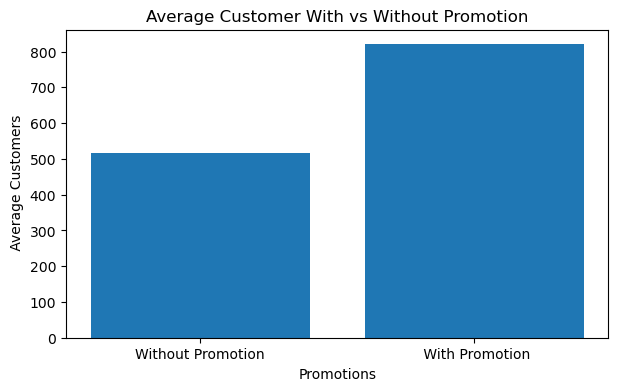

In [100]:
plt.figure(figsize = (7,4))
plt.bar(promo_customers.index,promo_customers.values)

plt.title("Average Customer With vs Without Promotion")
plt.xlabel("Promotions")
plt.ylabel(" Average Customers")

plt.xticks([0,1], labels = ["Without Promotion", " With Promotion"])
plt.show()

Promotional periods are associated with both higher customer counts and higher sales. This does not by itself establish that the promotion alone caused the increase.

In [136]:
train["SalesPerCustomer"] = np.where(
    train["Customers"] > 0,
    train["Sales"] / train["Customers"],
    np.nan)

promo_spc = train.groupby("Promo")["SalesPerCustomer"].mean()
print(promo_spc)

Promo
0     8.941128
1    10.178907
Name: SalesPerCustomer, dtype: float64


Without Promotion -> 8.94 sales per customer |
With Promotion    -> 10.18 sales per customer.
A Person buys more items when there is a promotion

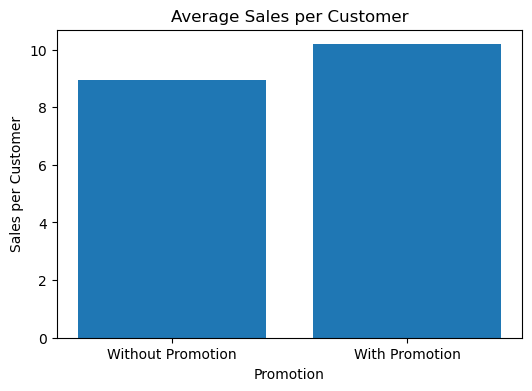

In [137]:
plt.figure(figsize=(6, 4))

plt.bar(promo_spc.index, promo_spc.values)

plt.title("Average Sales per Customer")
plt.xlabel("Promotion")
plt.ylabel("Sales per Customer")

plt.xticks(
    [0, 1],
    labels=["Without Promotion", "With Promotion"]
)

plt.show()

In [ ]:
# Promotions occur on weekdays but not on Saturdays or Sundays
promo_by_day = train.groupby("DayOfWeek")["Promo"].mean()
print(promo_by_day)

DayOfWeek
1    0.537276
2    0.532596
3    0.532592
4    0.531935
5    0.531935
6    0.000000
7    0.000000
Name: Promo, dtype: float64


In [142]:
# Keep only days when the store was open
open_train = train[train["Open"] == 1].copy()

In [ ]:
# Compare average sales with and without promotions within each weekday
promo_day_sales = (
    open_train
    .groupby(["DayOfWeek", "Promo"])["Sales"]
    .mean()
    .unstack()
)
print(promo_day_sales.round())

Promo           0       1
DayOfWeek                
1          6223.0  9773.0
2          5716.0  8277.0
3          5617.0  7685.0
4          5750.0  7598.0
5          6344.0  7744.0
6          5875.0     NaN
7          8225.0     NaN


Comparing sales on  each daysofWeek with promotion(1) and without promotion(0)

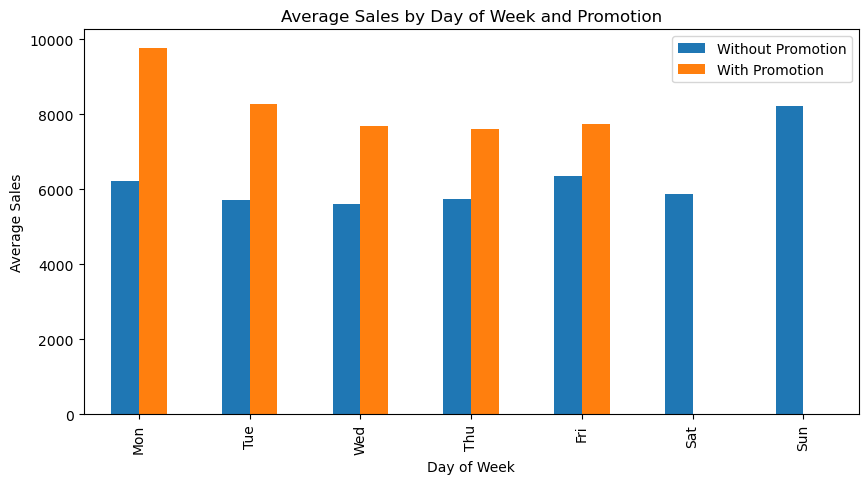

In [151]:
promo_day_sales_plot = promo_day_sales.copy()
promo_day_sales_plot.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

promo_day_sales_plot.plot(kind="bar",figsize=(10, 5))

plt.title("Average Sales by Day of Week and Promotion")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.legend(["Without Promotion", "With Promotion"])

plt.show()

## 6. Monthly and Yearly Sales Patterns

In [ ]:
# convert data to format 2013-01-01 -> 2013-01
train["Month"] = train["Date"].dt.to_period("M")

In [190]:
# Total Sales by Month
monthly_sales = train.groupby("Month")["Sales"].sum()
print(monthly_sales.head(3))
print(monthly_sales.tail(3))

Month
2013-01    180132207
2013-02    171534275
2013-03    201180369
Freq: M, Name: Sales, dtype: int64
Month
2015-05    189143897
2015-06    207363373
2015-07    212322616
Freq: M, Name: Sales, dtype: int64


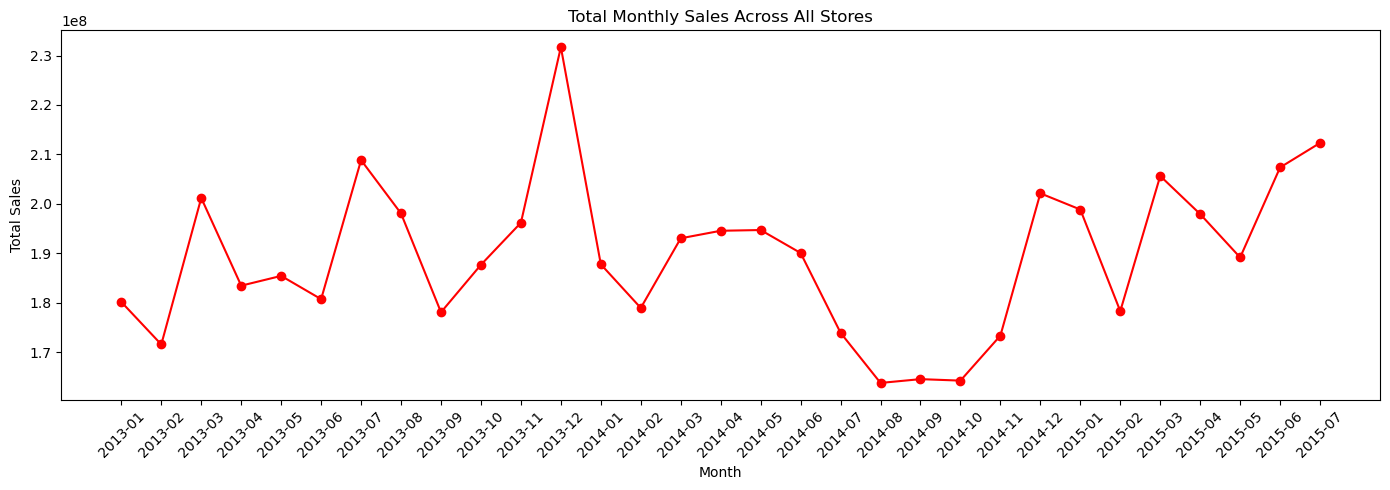

In [ ]:
# Total Sales by Month plot
plt.figure(figsize=(14, 5))

plt.plot(monthly_sales.index.astype(str),monthly_sales.values,marker="o",color = "red")

plt.title("Total Monthly Sales Across All Stores",)
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation = 45)
plt.tight_layout()

plt.show()

In [192]:
# Avg Sales by Month
monthly_sales = train.groupby("Month")["Sales"].mean().round()
print(monthly_sales.head(3))
print(monthly_sales.tail(3))

Month
2013-01    5212.0
2013-02    5494.0
2013-03    5820.0
Freq: M, Name: Sales, dtype: float64
Month
2015-05    5472.0
2015-06    6199.0
2015-07    6143.0
Freq: M, Name: Sales, dtype: float64


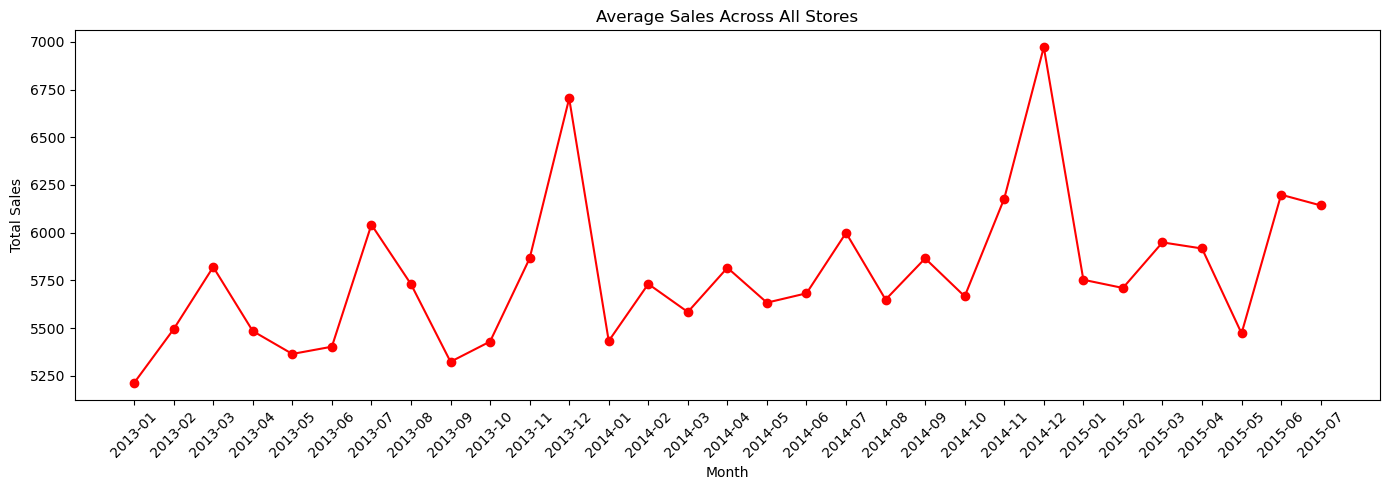

In [195]:
plt.figure(figsize=(14, 5))

plt.plot(monthly_sales.index.astype(str),monthly_sales.values,marker="o",color = "red")

plt.title("Average Sales Across All Stores",)
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation = 45)
plt.tight_layout()

plt.show()

In [ ]:
# Sales by Year
train["Year"] = train["Date"].dt.year

In [ ]:

yearly_sales = train.groupby("Year")["Sales"].mean().round()
print(yearly_sales)

Year
2013    5659.0
2014    5833.0
2015    5878.0
Name: Sales, dtype: float64


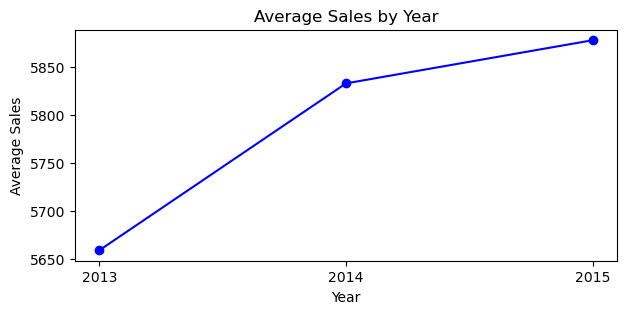

In [213]:
plt.figure(figsize = (7,3))
plt.plot(yearly_sales.index,yearly_sales.values,marker = 'o', color = "b")

plt.title("Average Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Sales")

plt.xticks(yearly_sales.index)

plt.show()

Average store-level daily sales increased from approximately 5,659 in 2013 to 5,833 in 2014 and 5,878 in the available portion of 2015, suggesting a modest upward trend. However, 2015 contains only partial-year data, so comparisons should be interpreted cautiously

## 7. Store Characteristics

In [214]:
# merge the store information

In [ ]:
# 'Left' Join Train and Store csv files on unique id 'Store' 
df = train.merge(store,on="Store",how="left")

print(df.shape)
df.head()


(1017209, 21)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,SalesPerCustomer,...,Year,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,2013-01-01,0,0,0,0,a,1,NaN,...,2013,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,2,2013-01-01,0,0,0,0,a,1,NaN,...,2013,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,2,2013-01-01,0,0,0,0,a,1,NaN,...,2013,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,2,2013-01-01,0,0,0,0,a,1,NaN,...,2013,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,2,2013-01-01,0,0,0,0,a,1,NaN,...,2013,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
# Sales generated by each type of store per daily record
storetype_sales = df.groupby("StoreType")["Sales"].mean()
print(storetype_sales)

StoreType
a     5738.179710
b    10058.837334
c     5723.629246
d     5641.819243
Name: Sales, dtype: float64


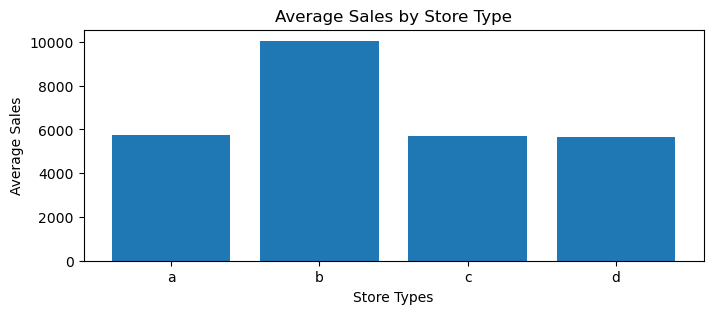

In [221]:
plt.figure(figsize=(8, 3))

plt.bar(storetype_sales.index, storetype_sales.values)

plt.title("Average Sales by Store Type")
plt.xlabel("Store Types")
plt.ylabel("Average Sales")

plt.show()

In [ ]:
# Average Sales by Assortment
# Check stores with different assortment categories have different average sales
assortment_sales = df.groupby("Assortment")["Sales"].mean()

print(assortment_sales) # variety of items a store offers


Assortment
a    5481.026096
b    8553.931999
c    6058.676567
Name: Sales, dtype: float64


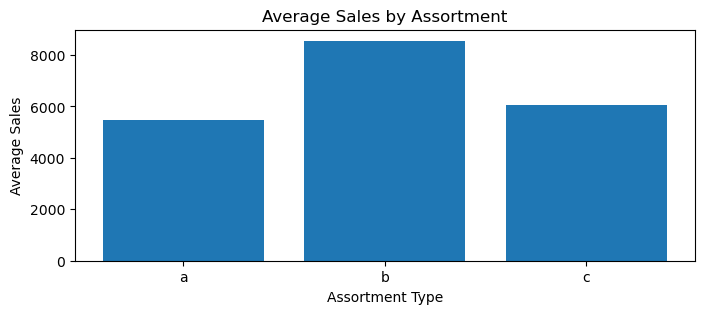

In [ ]:
plt.figure(figsize=(8, 3))

plt.bar(assortment_sales.index,assortment_sales.values)

plt.title("Average Sales by Assortment")
plt.xlabel("Assortment Type")
plt.ylabel("Average Sales")

plt.show()

## 8. Competition Analysis

In [225]:
# CompetitionDistance - distance in meters to the nearest competitor
df["CompetitionDistance"].isna().sum()

2642

In [ ]:
competition_data = df[["CompetitionDistance", "Sales"]].dropna()
# .corr() calc correlation between numerical column
print(competition_data.corr(numeric_only=True))

                     CompetitionDistance     Sales
CompetitionDistance             1.000000 -0.019229
Sales                          -0.019229  1.000000


In [228]:
#-1  - strong negative relationship
# 0   -  no linear relationship
# +1  - strong positive relationship
# As competition distance increases, sales tend to decrease slightly
# Competition distance alone does not appear to have a meaningful linear relationship with sales.


In [230]:
# Instead of plotting all 1 mil records , they are grouped with specific range
df["CompetitionDistanceGroup"] = pd.cut(df["CompetitionDistance"],
    bins=[0, 1000, 5000, 10000, 20000, np.inf],
    labels=[
        "0-1km",
        "1-5km",
        "5-10km",
        "10-20km",
        "20km+"
    ])

competition_sales = (
    df.groupby("CompetitionDistanceGroup", observed=True)["Sales"]
    .mean()
)

print(competition_sales)

CompetitionDistanceGroup
0-1km      6063.365791
1-5km      5675.492669
5-10km     5567.718124
10-20km    5573.341004
20km+      5937.308807
Name: Sales, dtype: float64


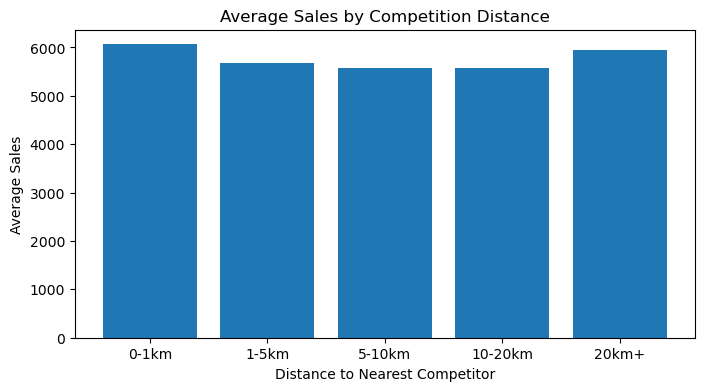

In [231]:
plt.figure(figsize=(8, 4))

plt.bar(competition_sales.index.astype(str),competition_sales.values)

plt.title("Average Sales by Competition Distance")
plt.xlabel("Distance to Nearest Competitor")
plt.ylabel("Average Sales")

plt.show()

Competition distance does not show a strong or consistent relationship with average sales. Stores with nearby competitors (0 to 1 km) have relatively high sales, while stores farther than 20 km also show high average sales. This suggests that competition distance alone is not sufficient to explain sales performance, and other factors such as store type, location, promotions, and customer demand may play a larger role.

## 9. Holiday Analysis

In [ ]:
# Average sales by StateHoliday
# Convert all values to strings (Some vals were integers before)
df["StateHoliday"] = df["StateHoliday"].astype(str)
# Recalculate average sales
holiday_sales = df.groupby("StateHoliday")["Sales"].mean()

print(holiday_sales)

StateHoliday
0    5947.483893
a     290.735686
b     214.311510
c     168.733171
Name: Sales, dtype: float64


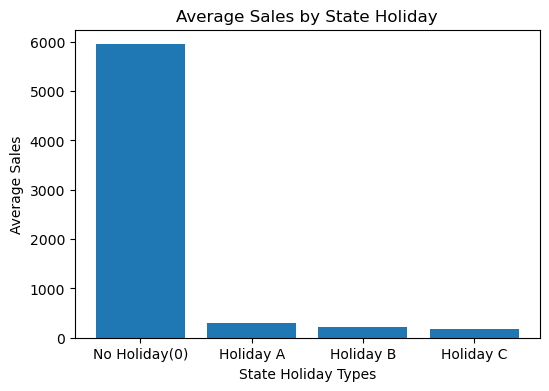

In [241]:
plt.figure(figsize=(6, 4))

plt.bar(holiday_sales.index.astype(str), holiday_sales.values)

plt.title("Average Sales by State Holiday")

plt.xlabel("State Holiday Types")

plt.ylabel("Average Sales")

plt.xticks(["0", "a", "b", "c"], ["No Holiday(0)", "Holiday A", "Holiday B", "Holiday C"])

plt.show()

Sales are lower on state holidays compared with non-holiday days. This may be partly explained by store closures or reduced operations during holidays.

In [ ]:
# check - School Holidays affect sales (For Open Stores)
open_df = df[df["Open"] == 1]

school_holiday_open = (open_df.groupby("SchoolHoliday")["Sales"].mean())

print(school_holiday_open)

SchoolHoliday
0    6896.782411
1    7200.181650
Name: Sales, dtype: float64


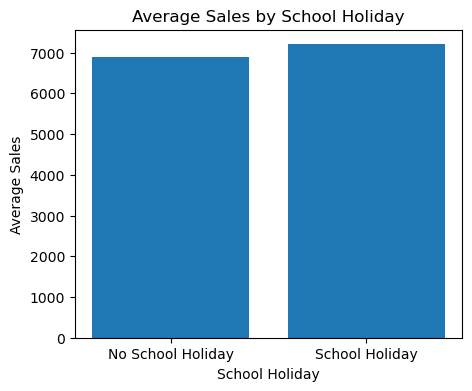

In [255]:
plt.figure(figsize=(5, 4))

plt.bar(school_holiday_open.index.astype(str),school_holiday_open.values)

plt.title("Average Sales by School Holiday")

plt.xlabel("School Holiday")
plt.ylabel("Average Sales")

plt.xticks([0, 1],["No School Holiday", "School Holiday"])

plt.show()

Sales have gone up slightly on School holidays although difference isn't huge.

# Key Findings

1. The dataset contains daily sales records from January 2013 to July 2015 across 1,115 stores.

2. Sales vary across days of the week. Monday has relatively high average sales, while Sunday has the lowest sales because most stores are closed.

3. Promotions are associated with higher average sales and increased customer traffic. Sales per customer are also higher during promotional periods.

4. Sales vary across months, indicating seasonal patterns that should be considered when building forecasting models.

5. Average sales increased slightly from 2013 to 2015, suggesting a modest overall upward trend.

6. Store characteristics, including store type and assortment, are associated with differences in average sales.

7. Competition distance does not show a strong or consistent relationship with average sales.

8. Sales are substantially lower during state holidays, likely influenced by store closures or reduced operations.

9. Average sales are somewhat higher during school holidays. This difference remains, although smaller, when comparing only stores that were open.

10. Overall, time-related patterns, promotions, holidays, store characteristics, and store operating status appear relevant for understanding and forecasting sales.

